# 03 — Signals Demo: Classical vs ML

This notebook compares classical arbitrage signaling outputs against actual ML signal strategy outputs, with advanced-method diagnostics shown separately.

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
TABLES = ROOT / 'project report' / 'tables'
PROCESSED = ROOT / 'data' / 'processed'

signals_path = PROCESSED / 'signals_latest.csv'
snapshot_path = PROCESSED / 'signals_latest_snapshot.csv'
diag_path = PROCESSED / 'signals_latest_diagnostics.csv'
adv_path = TABLES / 'tab_6_4_advanced_methods.csv'
pf_path = PROCESSED / 'portfolio_backtest_summary.csv'

ml_sig_path = PROCESSED / 'ml_signals.csv'
ml_snap_path = PROCESSED / 'ml_signals_snapshot.csv'
ml_diag_path = PROCESSED / 'ml_signals_diagnostics.csv'
ml_pf_path = PROCESSED / 'ml_backtest_summary.csv'

required = [
    signals_path, snapshot_path, diag_path, adv_path, pf_path,
    ml_sig_path, ml_snap_path, ml_diag_path, ml_pf_path
]
missing = [p for p in required if not p.exists()]
print(f'Missing artifacts: {len(missing)}')
for p in missing:
    print(' -', p)

if missing:
    display(Markdown('**Some ML artifacts are missing. Run `00_cache_and_run_control.ipynb` in full mode to regenerate.**'))

Missing artifacts: 0


In [10]:
signals = pd.read_csv(signals_path, parse_dates=['date']) if signals_path.exists() else pd.DataFrame()
snapshot = pd.read_csv(snapshot_path) if snapshot_path.exists() else pd.DataFrame()
diag = pd.read_csv(diag_path) if diag_path.exists() else pd.DataFrame()
adv = pd.read_csv(adv_path) if adv_path.exists() else pd.DataFrame()
pf = pd.read_csv(pf_path) if pf_path.exists() else pd.DataFrame()

ml_signals = pd.read_csv(ml_sig_path, parse_dates=['date']) if ml_sig_path.exists() else pd.DataFrame()
ml_snapshot = pd.read_csv(ml_snap_path) if ml_snap_path.exists() else pd.DataFrame()
ml_diag = pd.read_csv(ml_diag_path) if ml_diag_path.exists() else pd.DataFrame()
ml_pf = pd.read_csv(ml_pf_path) if ml_pf_path.exists() else pd.DataFrame()

display(Markdown('## Latest Classical Snapshot'))
display(snapshot)

display(Markdown('## Latest ML Snapshot'))
display(ml_snapshot)

display(Markdown('## Classical Signal Diagnostics'))
display(diag)

display(Markdown('## ML Signal Diagnostics'))
display(ml_diag)

display(Markdown('## Portfolio Summary (Classical)'))
display(pf)

display(Markdown('## Portfolio Summary (ML)'))
display(ml_pf)

display(Markdown('## Advanced Method Diagnostics (non-trading diagnostic block)'))
display(adv)

## Latest Classical Snapshot

,timestamp,signal_type,maturity_bucket,direction,strength,confidence
0,2026-05-21T04:35:09Z,spread,3M,0,1.4400,0.4800
1,2026-05-21T04:35:09Z,cip,3M,0,0.9400,0.3133
2,2026-05-21T04:35:09Z,spread,6M,0,1.3500,0.4500
3,2026-05-21T04:35:09Z,cip,6M,0,0.9900,0.3300
4,2026-05-21T04:35:09Z,spread,1Y,0,1.1400,0.3800
5,2026-05-21T04:35:09Z,cip,1Y,0,1.0600,0.3533
6,2026-05-21T04:35:09Z,spread,2Y,0,0.7900,0.2633
7,2026-05-21T04:35:09Z,cip,2Y,0,1.1400,0.3800
8,2026-05-21T04:35:09Z,spread,3Y,0,0.5400,0.1800
9,2026-05-21T04:35:09Z,cip,3Y,0,1.1800,0.3933


## Latest ML Snapshot

,timestamp,signal_type,maturity_bucket,direction,strength,confidence,proba_ensemble
0,2026-05-22T16:36:35.909455Z,ml,10Y_rel,1,0.11374,0.11374,0.55687


## Classical Signal Diagnostics

...

,strategy,ann_sharpe,max_drawdown,var95_empirical,mean_return
0,strategy,-0.2907,-0.0521,0.0053,-0.000262
1,naive_50_50,-0.2907,-0.0521,0.0053,-0.000262
2,disconnected_60_40,-0.3354,-0.0633,0.0063,-0.000358


## Portfolio Summary (ML)

,strategy,ann_sharpe,max_drawdown,var95_empirical,mean_return,hit_ratio,active_pct
0,ml_strategy,1.9348,-0.0024,0.0018,0.002083,0.5278,0.6389
1,ml_passive_spread,-0.8269,-0.0700,0.0112,-0.001422,0.3333,1.0000


## Advanced Method Diagnostics (non-trading diagnostic block)

,Method,Metric,Value,Notes
0,NS_baseline,RMSE_mean,0.141584,In-sample overall RMSE
1,AER_proxy,Objective_mean,0.025394,MSE + lambda * curvature penalty
2,AER_proxy,Penalty_mean,0.018732,Average curvature smoothness penalty
3,Regime_DNS,1step_RMSE_last,0.251929,Status=fitted; macro=global_indicators_DGS10


In [11]:
# Build a standardized comparison table
strategy_row = pf[pf['strategy'] == 'strategy'] if not pf.empty and 'strategy' in pf.columns else pd.DataFrame()
sharpe = float(strategy_row['ann_sharpe'].iloc[0]) if not strategy_row.empty else np.nan
dd = float(strategy_row['max_drawdown'].iloc[0]) if not strategy_row.empty else np.nan
var95 = float(strategy_row['var95_empirical'].iloc[0]) if not strategy_row.empty else np.nan

# Classical stability summary
classical = diag[diag['signal_type'].isin(['spread', 'cip', 'factor'])] if not diag.empty else pd.DataFrame()
flip = float(classical['flip_rate'].mean()) if not classical.empty else np.nan
persist = float(classical['persistence'].mean()) if not classical.empty else np.nan
active = float(classical['active_pct'].mean()) if not classical.empty else np.nan

# ML strategy metrics
ml_row = ml_pf[ml_pf['strategy'] == 'ml_strategy'] if not ml_pf.empty and 'strategy' in ml_pf.columns else pd.DataFrame()
ml_sharpe = float(ml_row['ann_sharpe'].iloc[0]) if not ml_row.empty else np.nan
ml_dd = float(ml_row['max_drawdown'].iloc[0]) if not ml_row.empty else np.nan
ml_var95 = float(ml_row['var95_empirical'].iloc[0]) if not ml_row.empty else np.nan
ml_active = float(ml_row['active_pct'].iloc[0]) if not ml_row.empty and 'active_pct' in ml_row.columns else np.nan
ml_hit = float(ml_row['hit_ratio'].iloc[0]) if not ml_row.empty and 'hit_ratio' in ml_row.columns else np.nan

ml_diag_map = dict(zip(ml_diag['metric'], ml_diag['value'])) if not ml_diag.empty and {'metric', 'value'}.issubset(ml_diag.columns) else {}
adv_metric = dict(zip(adv['Metric'], adv['Value'])) if not adv.empty and {'Metric', 'Value'}.issubset(adv.columns) else {}

comparison = pd.DataFrame([
    {
        'Model_family': 'Classical_signals (spread/cip/factor)',
        'Horizon_or_frequency': 'monthly signals',
        'Sharpe_primary': sharpe,
        'Max_drawdown': dd,
        'VaR95_empirical': var95,
        'Turnover_proxy': flip,
        'Signal_persistence': persist,
        'Signal_activity': active,
        'Extra_metric': 'n/a'
    },
    {
        'Model_family': 'ML_signals (logit + random forest ensemble)',
        'Horizon_or_frequency': 'monthly walk-forward',
        'Sharpe_primary': ml_sharpe,
        'Max_drawdown': ml_dd,
        'VaR95_empirical': ml_var95,
        'Turnover_proxy': 1.0 - ml_diag_map.get('directional_hit_when_active', np.nan) if 'directional_hit_when_active' in ml_diag_map else np.nan,
        'Signal_persistence': np.nan,
        'Signal_activity': ml_active,
        'Extra_metric': ml_hit
    },
    {
        'Model_family': 'ML_like diagnostics (AER proxy + regime DNS)',
        'Horizon_or_frequency': '1-step diagnostic only',
        'Sharpe_primary': np.nan,
        'Max_drawdown': np.nan,
        'VaR95_empirical': np.nan,
        'Turnover_proxy': np.nan,
        'Signal_persistence': np.nan,
        'Signal_activity': np.nan,
        'Extra_metric': adv_metric.get('Objective_mean', np.nan)
    }
])

display(Markdown('## Standardized Classical vs ML Comparison Table'))
display(comparison)

## Standardized Classical vs ML Comparison Table

,Model_family,Horizon_or_frequency,Sharpe_primary,Max_drawdown,VaR95_empirical,Turnover_proxy,Signal_persistence,Signal_activity,Extra_metric
0,Classical_signals (spread/cip/factor),monthly signals,-0.2907,-0.0521,0.0053,0.140137,0.850296,0.261788,n/a
1,ML_signals (logit + random forest ensemble),monthly walk-forward,1.9348,-0.0024,0.0018,0.521739,NaN,0.638900,0.5278
2,ML_like diagnostics (AER proxy + regime DNS),1-step diagnostic only,NaN,NaN,NaN,NaN,NaN,NaN,0.025394


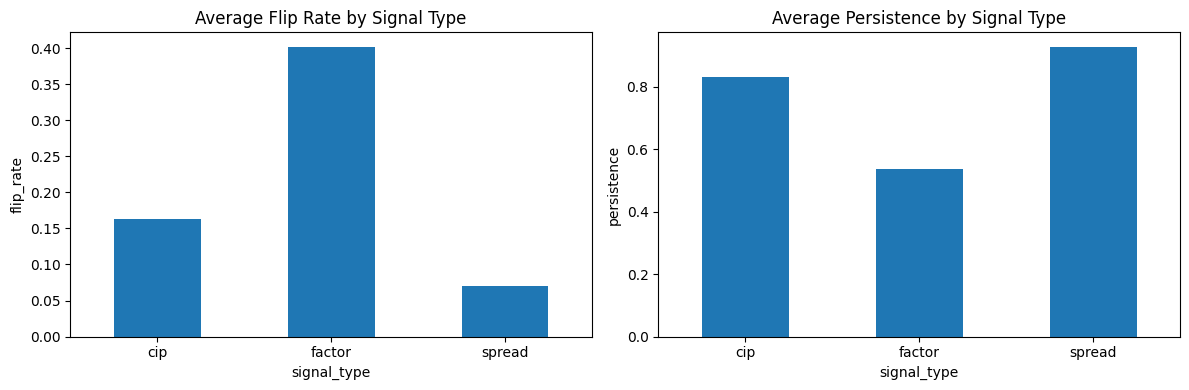

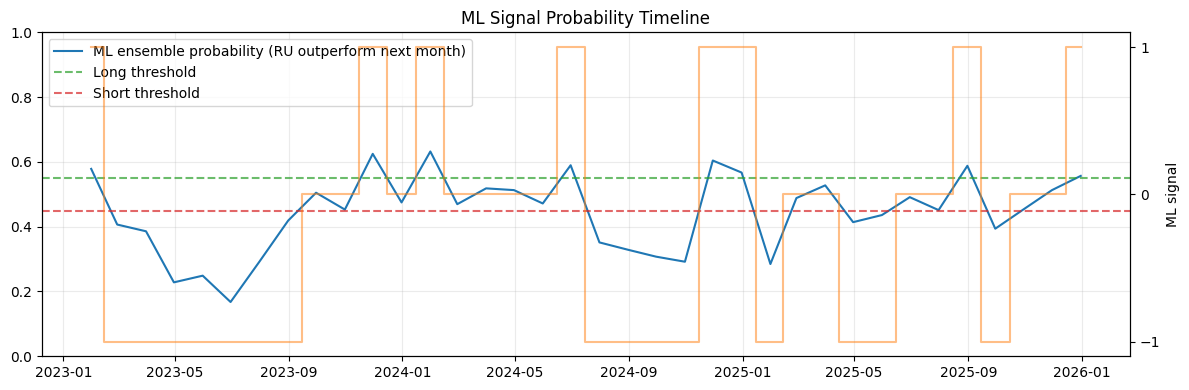

In [12]:
# Visualize stability by signal family + ML probability dynamics
if not diag.empty:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    by_type = diag.groupby('signal_type')[['flip_rate', 'persistence']].mean()
    by_type['flip_rate'].plot(kind='bar', ax=ax[0], title='Average Flip Rate by Signal Type', rot=0)
    by_type['persistence'].plot(kind='bar', ax=ax[1], title='Average Persistence by Signal Type', rot=0)
    ax[0].set_ylabel('flip_rate')
    ax[1].set_ylabel('persistence')
    plt.tight_layout()
    plt.show()

if not ml_signals.empty and {'proba_ensemble', 'ml_signal'}.issubset(ml_signals.columns):
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(ml_signals['date'], ml_signals['proba_ensemble'], label='ML ensemble probability (RU outperform next month)', color='tab:blue')
    ax1.axhline(0.55, linestyle='--', color='tab:green', alpha=0.7, label='Long threshold')
    ax1.axhline(0.45, linestyle='--', color='tab:red', alpha=0.7, label='Short threshold')
    ax1.set_ylim(0, 1)
    ax1.set_title('ML Signal Probability Timeline')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    ax2.step(ml_signals['date'], ml_signals['ml_signal'], where='mid', color='tab:orange', alpha=0.5, label='ML signal')
    ax2.set_yticks([-1, 0, 1])
    ax2.set_ylabel('ML signal')
    plt.tight_layout()
    plt.show()

## Notes

- This notebook now includes **actual ML trading signals** with walk-forward evaluation and portfolio metrics.
- The `tab_6_4_advanced_methods.csv` block remains a diagnostic comparison (AER proxy / regime DNS), not a direct trading backtest.

In [13]:
# Major results summary (signals: classical vs ML)
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'project report' / 'tables'

pf_path = PROCESSED / 'portfolio_backtest_summary.csv'
ml_pf_path = PROCESSED / 'ml_backtest_summary.csv'
ml_diag_path = PROCESSED / 'ml_signals_diagnostics.csv'
diag_path = PROCESSED / 'signals_latest_diagnostics.csv'
adv_path = TABLES / 'tab_6_4_advanced_methods.csv'

missing = [p for p in [pf_path, ml_pf_path, ml_diag_path, diag_path] if not p.exists()]
if missing:
    display(Markdown('**Major-results summary unavailable:** some signal/backtest artifacts are missing.'))
else:
    pf = pd.read_csv(pf_path)
    ml_pf = pd.read_csv(ml_pf_path)
    ml_diag = pd.read_csv(ml_diag_path)
    diag = pd.read_csv(diag_path)

    classical_row = pf[pf['strategy'] == 'strategy'].head(1)
    ml_row = ml_pf[ml_pf['strategy'] == 'ml_strategy'].head(1)

    classical_summary = {
        'family': 'Classical (spread/cip/factor)',
        'ann_sharpe': float(classical_row['ann_sharpe'].iloc[0]) if not classical_row.empty else np.nan,
        'max_drawdown': float(classical_row['max_drawdown'].iloc[0]) if not classical_row.empty else np.nan,
        'var95_empirical': float(classical_row['var95_empirical'].iloc[0]) if not classical_row.empty else np.nan,
        'mean_return': float(classical_row['mean_return'].iloc[0]) if not classical_row.empty else np.nan,
        'active_pct': float(diag['active_pct'].mean()) if not diag.empty else np.nan,
    }
    ml_summary = {
        'family': 'ML (logit + random forest ensemble)',
        'ann_sharpe': float(ml_row['ann_sharpe'].iloc[0]) if not ml_row.empty else np.nan,
        'max_drawdown': float(ml_row['max_drawdown'].iloc[0]) if not ml_row.empty else np.nan,
        'var95_empirical': float(ml_row['var95_empirical'].iloc[0]) if not ml_row.empty else np.nan,
        'mean_return': float(ml_row['mean_return'].iloc[0]) if not ml_row.empty else np.nan,
        'active_pct': float(ml_row['active_pct'].iloc[0]) if (not ml_row.empty and 'active_pct' in ml_row.columns) else np.nan,
    }

    cmp = pd.DataFrame([classical_summary, ml_summary])

    display(Markdown('## Major Results — Classical vs ML Signals'))
    display(cmp.round(4))

    if {'metric', 'value'}.issubset(ml_diag.columns):
        md = dict(zip(ml_diag['metric'], ml_diag['value']))
        ml_diag_summary = pd.DataFrame([
            {
                'n_predictions': md.get('n_predictions', np.nan),
                'trade_rate': md.get('trade_rate', np.nan),
                'accuracy': md.get('accuracy', np.nan),
                'f1': md.get('f1', np.nan),
                'roc_auc': md.get('roc_auc', np.nan),
                'directional_hit_when_active': md.get('directional_hit_when_active', np.nan),
            }
        ])
        display(Markdown('### ML diagnostic quality metrics'))
        display(ml_diag_summary.round(4))

if adv_path.exists():
    adv = pd.read_csv(adv_path)
    display(Markdown('### Advanced methods diagnostic block (non-trading reference)'))
    display(adv)

## Major Results — Classical vs ML Signals

,family,ann_sharpe,max_drawdown,var95_empirical,mean_return,active_pct
0,Classical (spread/cip/factor),-0.2907,-0.0521,0.0053,-0.0003,0.2618
1,ML (logit + random forest ensemble),1.9348,-0.0024,0.0018,0.0021,0.6389


### ML diagnostic quality metrics

,n_predictions,trade_rate,accuracy,f1,roc_auc,directional_hit_when_active
0,36.0,0.6389,0.3611,0.08,0.4201,0.4783


### Advanced methods diagnostic block (non-trading reference)

,Method,Metric,Value,Notes
0,NS_baseline,RMSE_mean,0.141584,In-sample overall RMSE
1,AER_proxy,Objective_mean,0.025394,MSE + lambda * curvature penalty
2,AER_proxy,Penalty_mean,0.018732,Average curvature smoothness penalty
3,Regime_DNS,1step_RMSE_last,0.251929,Status=fitted; macro=global_indicators_DGS10
